# Data retrieval

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
cca_df = pd.read_csv(r'credit+approval/crx.csv')
cca_df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43,560,+
2,a,24.5,0.500,u,g,q,h,1.50,t,f,0,f,g,280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120,0,+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,b,21.08,10.085,y,p,e,h,1.25,f,f,0,f,g,260,0,-
686,a,22.67,0.750,u,g,c,v,2.00,f,t,2,t,g,200,394,-
687,a,25.25,13.500,y,p,ff,ff,2.00,f,t,1,t,g,200,1,-
688,b,17.92,0.205,u,g,aa,v,0.04,f,f,0,f,g,280,750,-


In [3]:
cca_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      690 non-null    object 
 1   A2      690 non-null    object 
 2   A3      690 non-null    float64
 3   A4      690 non-null    object 
 4   A5      690 non-null    object 
 5   A6      690 non-null    object 
 6   A7      690 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null    object 
 10  A11     690 non-null    int64  
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     690 non-null    object 
 14  A15     690 non-null    int64  
 15  A16     690 non-null    object 
dtypes: float64(2), int64(2), object(12)
memory usage: 86.4+ KB


In [4]:
cca_df.describe()

,A3,A8,A11,A15
count,690.000000,690.000000,690.00000,690.000000
mean,4.758725,2.223406,2.40000,1017.385507
std,4.978163,3.346513,4.86294,5210.102598
min,0.000000,0.000000,0.00000,0.000000
25%,1.000000,0.165000,0.00000,0.000000
50%,2.750000,1.000000,0.00000,5.000000
75%,7.207500,2.625000,3.00000,395.500000
max,28.000000,28.500000,67.00000,100000.000000


# Data cleaning

## Duplicates

In [5]:
cca_df.duplicated().sum()

np.int64(0)

## Missing values

In [6]:
# We can't directly detect missing values thus we go to the description
cca_df.isna().sum()

A1     0
A2     0
A3     0
A4     0
A5     0
A6     0
A7     0
A8     0
A9     0
A10    0
A11    0
A12    0
A13    0
A14    0
A15    0
A16    0
dtype: int64

In [7]:
cca_df.isin(['?']).sum()

A1     12
A2     12
A3      0
A4      6
A5      6
A6      9
A7      9
A8      0
A9      0
A10     0
A11     0
A12     0
A13     0
A14    13
A15     0
A16     0
dtype: int64

### A1 - 12

In [11]:
# Extract the rows with missing values -- Entries that aren't containing a or b
# Use bitwsise operators for more specificity
a1_w_na = cca_df[~cca_df['A1'].isin(['a','b'])].index
# Remove each of those rows
for i in a1_w_na:
    cca_df.drop(index=i, inplace=True)
# Check whether they have been removed
cca_df[~cca_df['A1'].isin(['a','b'])]

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16


### A2 - 12

In [144]:
# Extract the rows with missing values -- Entries containing '?' instead of a number
# Use bitwsise operators for more specificity
a2_w_na = cca_df[cca_df['A2'] == '?'].index
# Remove each of those rows
for i in a2_w_na:
    cca_df.drop(index=i, inplace=True)
# Check whether they have been removed
cca_df[cca_df['A2'] == '?']

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16


### A4 - 6

In [145]:
# Extract the rows with missing values -- Entries not containing u, y, l, t.
# Use bitwsise operators for more specificity 
a4_w_na = cca_df[~cca_df['A4'].isin(['u','y','l','t'])].index
# Remove each of those rows
for i in a4_w_na:
    cca_df.drop(index=i, inplace=True)
# Check whether they have been removed
cca_df[~cca_df['A4'].isin(['u','y','l','t'])]

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16


### A5 - 6

In [146]:
# Extract the rows with missing values -- Entries not containing g, p, gg
# Use bitwsise operators for more specificity 
a5_w_na = cca_df[~cca_df['A5'].isin(['g','p','gg'])].index
# Remove each of those rows
for i in a5_w_na:
    cca_df.drop(index=i, inplace=True)
# Check whether they have been removed
cca_df[~cca_df['A5'].isin(['g','p','gg'])]

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16


### A6 - 9

In [147]:
# Extract the rows with missing values -- Entries not containing c, d, cc, i, j, k, m, r, q, w, x, e, aa, ff
# Use bitwsise operators for more specificity 
a6_w_na = cca_df[~cca_df['A6'].isin(['c','d','cc','i','j','k','m','r','q','w','x','e','aa','ff'])].index
# Remove each of those rows
for i in a6_w_na:
    cca_df.drop(index=i, inplace=True)
# Check whether they have been removed
cca_df[~cca_df['A6'].isin(['c','d','cc','i','j','k','m','r','q','w','x','e','aa','ff'])]

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16


### A7 - 9

In [148]:
# Extract the rows with missing values -- Entries not containing v, h, bb, j, n, z, dd, ff, o
# Use bitwsise operators for more specificity 
a7_w_na = cca_df[~cca_df['A7'].isin(['v','h','bb','j','n','z','dd','ff','o'])].index
# Remove each of those rows
for i in a7_w_na:
    cca_df.drop(index=i, inplace=True)
# Check whether they have been removed
cca_df[~cca_df['A7'].isin(['v','h','bb','j','n','z','dd','ff','o'])]

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16


### A14 - 13

In [149]:
# Extract the rows with missing values -- Entries containing '?' instead of a number
# Use bitwsise operators for more specificity 
a14_w_na = cca_df[cca_df['A14'] == '?'].index
# Remove each of those rows
for i in a14_w_na:
    cca_df.drop(index=i, inplace=True)
# Check whether they have been removed
cca_df[cca_df['A14'] == '?']

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16


### Verify that na has been addressed entirely

In [150]:
cca_df.isin(['?']).sum()

A1     0
A2     0
A3     0
A4     0
A5     0
A6     0
A7     0
A8     0
A9     0
A10    0
A11    0
A12    0
A13    0
A14    0
A15    0
A16    0
dtype: int64

## Outliers

In [151]:
# Get numerical cols from the data source
numerical_cols = ['A2','A3','A8','A11','A14','A15']

In [152]:
# Some cols are wrongly tagged as categorical instead of numerical_cols 
# Such as A2 and A14
cca_df[numerical_cols].describe()

,A3,A8,A11,A15
count,653.000000,653.000000,653.000000,653.000000
mean,4.829533,2.244296,2.502297,1013.761103
std,5.027077,3.371120,4.968497,5253.278504
min,0.000000,0.000000,0.000000,0.000000
25%,1.040000,0.165000,0.000000,0.000000
50%,2.835000,1.000000,0.000000,5.000000
75%,7.500000,2.625000,3.000000,400.000000
max,28.000000,28.500000,67.000000,100000.000000


In [153]:
# Fix that ish
cca_df['A2'] = cca_df['A2'].astype('float')
cca_df['A14'] = cca_df['A14'].astype('float')

In [154]:
cca_df[numerical_cols].describe()

,A2,A3,A8,A11,A14,A15
count,653.000000,653.000000,653.000000,653.000000,653.000000,653.000000
mean,31.503813,4.829533,2.244296,2.502297,180.359877,1013.761103
std,11.838267,5.027077,3.371120,4.968497,168.296811,5253.278504
min,13.750000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.580000,1.040000,0.165000,0.000000,73.000000,0.000000
50%,28.420000,2.835000,1.000000,0.000000,160.000000,5.000000
75%,38.250000,7.500000,2.625000,3.000000,272.000000,400.000000
max,76.750000,28.000000,28.500000,67.000000,2000.000000,100000.000000


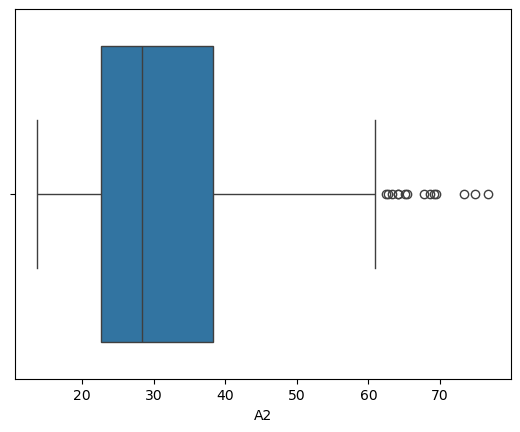

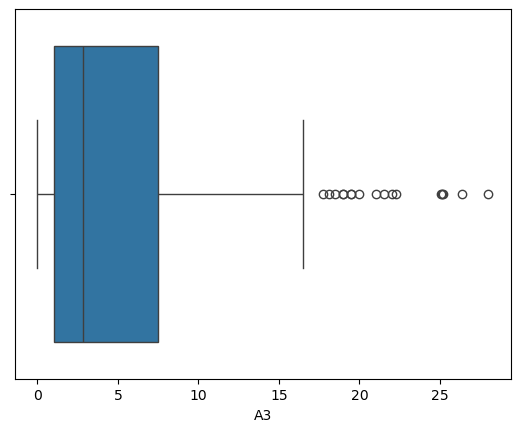

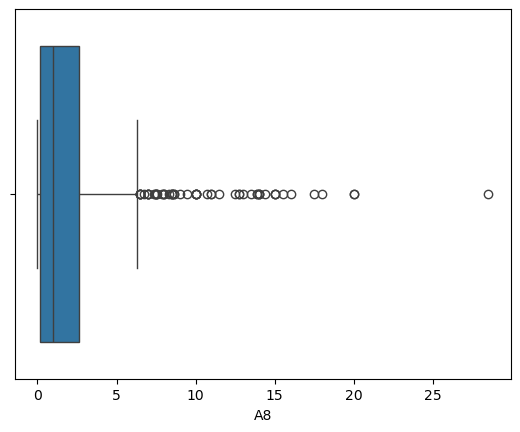

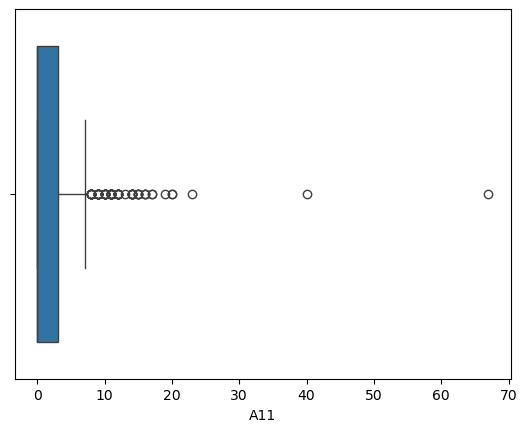

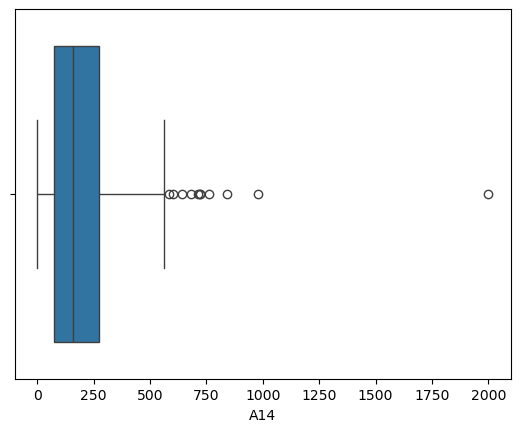

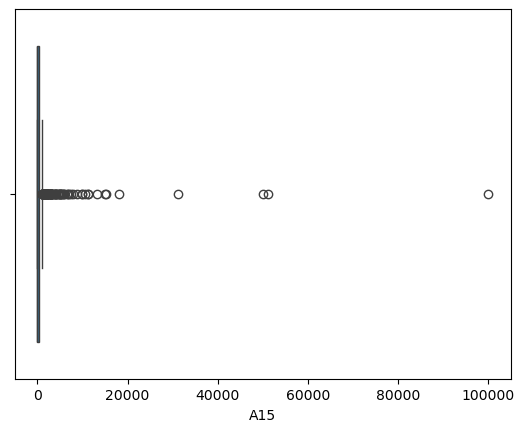

In [155]:
for col in numerical_cols:
    plt.figure()
    sns.boxplot(cca_df[col], orient='h')
    plt.show()

In [156]:
# I might have to play with this to improve metrics
from scipy.stats.mstats import winsorize

for col in numerical_cols:
    cca_df[col] = winsorize(cca_df[col], limits=[0.04, 0.04])

# Data preprocessing

## Label encoding 

In [157]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = cca_df.drop(numerical_cols, axis=1).columns
le = LabelEncoder()

for col in categorical_cols:
    cca_df[col] = le.fit_transform(cca_df[col])

cca_df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,1,30.83,0.165,1,0,12,7,1.25,1,1,1,0,0,202.0,0,0
1,0,57.08,4.460,1,0,10,3,3.04,1,1,6,0,0,43.0,560,0
2,0,24.50,0.500,1,0,10,3,1.50,1,0,0,0,0,280.0,824,0
3,1,27.83,1.540,1,0,12,7,3.75,1,1,5,1,0,100.0,3,0
4,1,20.17,5.625,1,0,12,7,1.71,1,0,0,0,2,120.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,1,21.08,10.085,2,2,4,3,1.25,0,0,0,0,0,260.0,0,1
686,0,22.67,0.750,1,0,1,7,2.00,0,1,2,1,0,200.0,394,1
687,0,25.25,13.500,2,2,5,2,2.00,0,1,1,1,0,200.0,1,1
688,1,17.92,0.205,1,0,0,7,0.04,0,0,0,0,0,280.0,750,1


## Standardization

In [158]:
# Apparently when you have one or more cols with high ranges, you have to standardize all cols not just one
from sklearn.preprocessing import StandardScaler

In [159]:
ss = StandardScaler()

for col in numerical_cols:
    cca_df[col] = ss.fit_transform(cca_df[[col]])

cca_df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,1,-0.041555,-1.002295,1,0,12,7,-0.305977,1,1,-0.343335,0,0,0.205520,-0.456811,0
1,0,2.333355,-0.042828,1,0,10,3,0.374142,1,1,1.035496,0,0,-0.936801,0.004187,0
2,0,-0.614248,-0.927459,1,0,10,3,-0.210988,1,0,-0.619101,0,0,0.765904,0.221514,0
3,1,-0.312973,-0.695132,1,0,12,7,0.643909,1,1,0.759730,1,0,-0.527289,-0.454341,0
4,1,-1.005995,0.217424,1,0,12,7,-0.131198,1,0,-0.619101,0,2,-0.383601,-0.456811,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,1,-0.923665,1.213751,2,2,4,3,-0.305977,0,0,-0.619101,0,0,0.622216,-0.456811,1
686,0,-0.779813,-0.871611,1,0,1,7,-0.021011,0,1,-0.067569,1,0,0.191152,-0.132466,1
687,0,-0.546393,1.976634,2,2,5,2,-0.021011,0,1,-0.343335,1,0,0.191152,-0.455988,1
688,1,-1.209558,-0.993360,1,0,0,7,-0.765722,0,0,-0.619101,0,0,0.765904,0.160596,1


# Data splitting

### Splitting

In [160]:
from sklearn.model_selection import train_test_split

In [161]:
y = cca_df['A16']
X = cca_df.drop('A16', axis=1)

In [198]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Oversample

In [199]:
y_train.value_counts(normalize=True)*100

A16
1    54.04814
0    45.95186
Name: proportion, dtype: float64

In [200]:
from imblearn.over_sampling import SMOTE

smt = SMOTE()
X_resampled, y_resampled = smt.fit_resample(X_train, y_train)

In [201]:
y_resampled.value_counts(normalize=True)*100

A16
0    50.0
1    50.0
Name: proportion, dtype: float64

# Model training

In [202]:
from sklearn.linear_model import LogisticRegression

In [203]:
logr_model = LogisticRegression()
logr_model.fit(X_resampled, y_resampled)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## RFE 

In [204]:
# from sklearn.feature_selection import RFE

# rfe = RFE(estimator=logr_model, n_features_to_select=6)
# rfe.fit(X, y)

# selected_features = X.columns[rfe.support_]
# selected_features

In [205]:
# X_train = X_train[selected_features]
# X_test = X_test[selected_features]

### Retraining

In [206]:
# logr_model.fit(X_train, y_train)

# Evaluation

In [207]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score

In [219]:
# Adjust threshold to fix precision
# Pr. for class +
# Returns the probabilities of each x_test value
y_probs = logr_model.predict_proba(X_test)[:,1]
threshold = 0.6
y_probs

array([0.43582525, 0.544613  , 0.00156354, 0.93489628, 0.95556437,
       0.95860109, 0.84777527, 0.00996523, 0.24154727, 0.9754257 ,
       0.38831387, 0.5625625 , 0.91673633, 0.21122932, 0.97605328,
       0.28429264, 0.07839808, 0.97049592, 0.05736671, 0.95084293,
       0.08573039, 0.1718032 , 0.83391434, 0.98154381, 0.25794025,
       0.11057122, 0.98216342, 0.79958631, 0.94088034, 0.90553463,
       0.00165583, 0.80897777, 0.34340603, 0.03548155, 0.89153588,
       0.14569226, 0.06549865, 0.85571537, 0.89532078, 0.88692446,
       0.91363743, 0.93140088, 0.43020158, 0.91663079, 0.38929952,
       0.20560331, 0.8795257 , 0.43381369, 0.97550851, 0.17379881,
       0.6147131 , 0.91139816, 0.39192323, 0.75722413, 0.97998129,
       0.08791178, 0.96048406, 0.15052786, 0.80776995, 0.17614948,
       0.32656729, 0.97533165, 0.94524459, 0.12652309, 0.05078884,
       0.25043295, 0.95969628, 0.97541349, 0.97011794, 0.63929564,
       0.96149788, 0.5387474 , 0.02568324, 0.96866181, 0.92057

In [220]:
# Any value >= threshold becomes 1 and any value less turns to 0
y_pred = (y_probs >= threshold).astype(int)
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1])

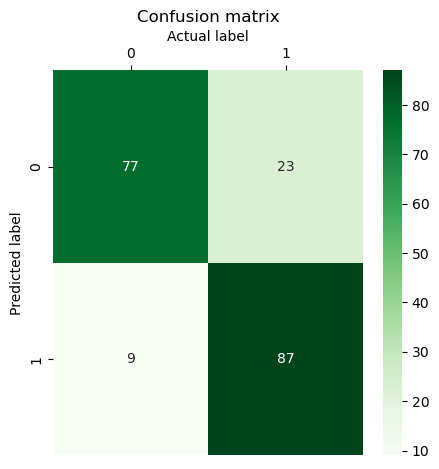

In [221]:
cmx = confusion_matrix(y_test, y_pred)
# Takes the transpose to make it the way I know it
cmx = cmx.T
# Heatmap representation of cmx
plt.figure(figsize=(5,5))
ax = sns.heatmap(cmx, cmap='Greens', annot=True, fmt='d')
plt.title('Confusion matrix')
plt.xlabel('Actual label')
plt.ylabel('Predicted label')
ax.xaxis.set_label_position("top")
ax.xaxis.tick_top()

In [222]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8367346938775511

In [223]:
# Precision should be higher than recall
precision = precision_score(y_test, y_pred)
precision

0.90625

In [224]:
recall = recall_score(y_test, y_pred)
recall

0.7909090909090909

In [225]:
f1_score = f1_score(y_test, y_pred)
f1_score

TypeError: 'float' object is not callable

# Visualization

# Test

In [ ]:
# Check the testset
X_test

In [ ]:
# Create test
my_test = pd.DataFrame({
    'A4': [1,2,1,1,2],
    'A8': [0.04,0.45,0.3,0.22,0.28],
    'A9': [1,0,0,1,1],
    'A10': [1,1,1,0,1],
    'A11': [10,20,25,30,65],
    'A15': [50,59,60,70,99]
})
my_test

In [ ]:
# Standardize
# Continuous cols
my_test_num_cols = ['A8','A11','A15']

for col in my_test_num_cols:
    my_test[col] = ss.fit_transform(my_test[[col]])

my_test

In [ ]:
# Predict
logr_model.predict(my_test)